In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interactive
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

N = 100 #number of particles

source_position = np.array([0.0, 0.0, 0.0])
source_direction = np.array([1.0, -1.0, 2.0])
source_radius = 1.0
source_beam_angle_deg = 25
source_power = 1000

mirror_position = np.array([2.5, -2.0, 4.0])
mirror_normal = np.array([-1.0, 1.0, -2.0])
mirror_radius = 2.0

In [2]:
#classes
class Torch:
    def __init__(self, position, direction, radius, beam_angle_deg, power):
        self.position = np.array(position, dtype=float)
        self.direction = unit(direction)
        self.radius = radius
        self.beam_angle = np.radians(beam_angle_deg)
        self.power = power
        self.R = create_R(direction)

class Mirror:
    def __init__(self, position, normal, radius):
        self.position = np.array(position, dtype=float)
        self.normal = unit(normal)
        self.radius = radius

In [3]:
#create unit vector
def unit(v, axis=-1):
    return v / np.linalg.norm(v, axis=axis, keepdims=True)

#reflection law
def reflect(directions, normal):
    return directions - 2 * (directions @ normal)[:, None] * normal

#ray generation based on torch
def generate_rays(torch, N):

    #position
    r = torch.radius*np.sqrt(np.random.rand(N))
    phi = 2*np.pi*np.random.rand(N)

    x_local = r*np.cos(phi)
    y_local = r*np.sin(phi)

    local = np.stack([x_local, y_local, np.zeros(N)], axis=1)

    #direction
    theta = (r*torch.beam_angle)/torch.radius

    dir_local = np.stack([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)],
        axis=1)

    #offset caused by torch direction
    origins = torch.position + local @ torch.R.T
    directions = dir_local @ torch.R.T

    directions = unit(directions)
    
    return origins, directions

#rotational matrix based on torch
def create_R(direction):
    forward = unit(direction)

    #makes sure temporary vector is not parallel
    if abs(forward[2]) < 0.99:
        temp = np.array([0,0,1])
    else:
        temp = np.array([0,1,0])
     
    #generate orthonormal basis
    right = np.cross(temp, forward)
    right = unit(right)

    up = np.cross(forward, right)

    #transformation matrix
    R = np.column_stack([right, up, forward])
    return R

def find_hits(
    rays_origin,
    rays_direction,
    mirror_position,
    mirror_normal,
    mirror_radius):

    #check if parallel
    denom = rays_direction @ mirror_normal
    valid = np.abs(denom) > 1e-8

    #find t where rays intersect plane
    t = np.full(len(rays_origin), np.inf)
    t[valid] = ((mirror_position - rays_origin[valid]) @ mirror_normal)/denom[valid]

    #find points where rays intersect plane
    P = rays_origin+rays_direction*t[:, None]

    #determine if points are within mirror
    mask_radius = np.linalg.norm(P - mirror_position, axis=1) <= mirror_radius
    hit_mask = (valid & (t > 0) & mask_radius)

    return P, t, hit_mask

def bounce(
    rays_origin,
    rays_direction,
    mirror_position,
    mirror_normal,
    mirror_radius):
    
    #find hits
    P, t, hit_mask = find_hits(
        rays_origin,
        rays_direction,
        mirror_position,
        mirror_normal,
        mirror_radius)

    #select hit rays
    origins_hit = rays_origin[hit_mask]
    directions_hit = rays_direction[hit_mask]
    P_hit = P[hit_mask]

    #reflect
    reflected = directions_hit-2*(directions_hit @ mirror_normal)[:, None]*mirror_normal
    reflected = unit(reflected, axis=1)

    #new rays
    new_origins = P_hit + reflected * 1e-6
    new_directions = reflected

    #segments
    segments = np.stack([origins_hit, P_hit], axis=1)
    return new_origins, new_directions, segments


def trace_rays(
    rays_origin,
    rays_direction,
    mirror_position,
    mirror_normal,
    mirror_radius,
    n_bounces=5,
    miss_distance=10):

    hit_bounces = []
    miss_segments = []

    for bounce in range(n_bounces):

        P, t, hit_mask = find_hits(
            rays_origin,
            rays_direction,
            mirror_position,
            mirror_normal,
            mirror_radius)

        #rays that hit
        hit_segments = np.stack([rays_origin[hit_mask], P[hit_mask]], axis=1)

        hit_bounces.append(hit_segments)

        # rays that miss
        miss_mask = ~hit_mask
        miss_end = (rays_origin[miss_mask]+rays_direction[miss_mask] * miss_distance)
        miss_segments.append(np.stack([rays_origin[miss_mask], miss_end], axis=1))

        # stop if nothing hit
        if not np.any(hit_mask):
            break

        # reflect hit rays
        reflected = (
            rays_direction[hit_mask]-2*(rays_direction[hit_mask] @ mirror_normal)
            [:, None]*mirror_normal)

        reflected = unit(reflected)

        origins = P[hit_mask] + reflected * 1e-6
        directions = reflected

    return hit_bounces, miss_segments

def plot_mirror(ax, mirror_position, mirror_normal, mirror_radius, N=50):

    normal = unit(mirror_normal)

    # build basis
    if abs(normal[2]) < 0.99:
        temp = np.array([0,0,1])
    else:
        temp = np.array([0,1,0])

    right = unit(np.cross(temp, normal))
    up = np.cross(normal, right)

    angles = np.linspace(0, 2*np.pi, N)

    circle = np.array([
        mirror_position+mirror_radius*(np.cos(a)*right+np.sin(a)*up)
        for a in angles])

    # outline
    ax.plot(circle[:,0], circle[:,1], circle[:,2], color='black')

    # filled disk
    poly = Poly3DCollection([circle], alpha=0.3)

    ax.add_collection3d(poly)

In [4]:
torch = Torch(
    source_position,
    source_direction,
    source_radius,
    source_beam_angle_deg,
    source_power)
mirror = Mirror(
    mirror_position,
    mirror_normal,
    mirror_radius)

rays_origin, rays_direction = generate_rays(torch, N)

hit_bounces, miss_segments = trace_rays(
    rays_origin,
    rays_direction,
    mirror_position,
    mirror_normal,
    mirror_radius,
    n_bounces=5)

colors = ["orange", "red", "purple", "blue", "green"]

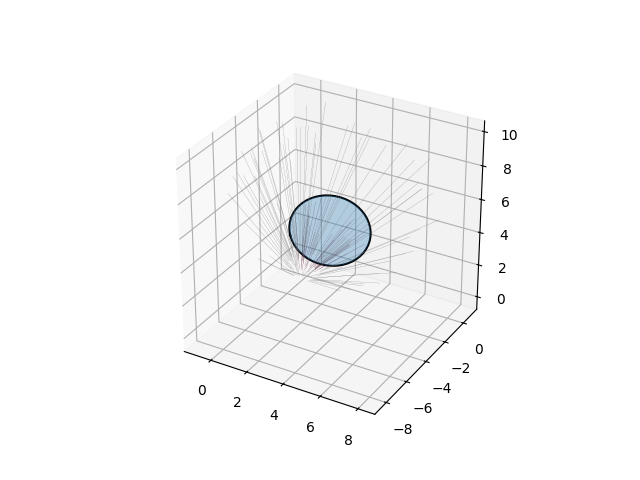

In [5]:
%matplotlib widget
#plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for bounce_segments, color in zip(hit_bounces, colors):
    ax.add_collection(Line3DCollection(bounce_segments, colors=color, linewidths=0.03))

all_miss = np.concatenate(miss_segments, axis=0)
ax.add_collection(Line3DCollection(all_miss, colors='gray', linewidth=0.03))

all_hits = np.concatenate(hit_bounces, axis=0)

all_points = np.concatenate([all_hits.reshape(-1, 3), all_miss.reshape(-1, 3)])

ax.auto_scale_xyz(all_points[:,0], all_points[:,1], all_points[:,2])

ax.set_box_aspect([1,1,1])
plot_mirror(ax, mirror_position, mirror_normal, mirror_radius)
# ax.view_init(elev=90, azim=0)    # top-down
# ax.view_init(elev=0, azim=0)     # side view
# ax.view_init(elev=30, azim=45)   # isometric
plt.show()

In [6]:
# received_fraction = hits / total_rays

# ray.power = total_power / n_rays
a = 1